# Pre filtered runs part of the AugComparison Sweep

All runs were in the same project, so simply running the following command in the `QueShell` will create the **runs.json** file:

```bash
list old -f wandb project -c x == AugComparison -s results test average_loss -op ~/Code/SLR/src/results/aug_comparison/runs.json
```

See the sweep [README.md](../../configfiles/AugComparison/README.md).
See the Que [README.md](../../que/README.md).

#####  Contents:
- [Imports](results.ipynb#imports)
    - [Helper Methods](#helper-methods)
    - [Load Runs](#load-runs)
    - [Metrics and Variables](#metrics-and-variables)
- [Prepare Data](#prepare-data-for-plotting)
    
    - [Convert to Dataframe](#convert-to-dataframe)
        - [All](#all)
        - [Averaged Runs](#averaged-runs)
- [Plot Data](#plot-data)
    - [Spatial Augs](#spatial-augs)
    - [Temporal Augs](#temporal-augs)


## Imports 

### Helper Methods

In [1]:
from pathlib import Path
from typing import cast

import matplotlib.pyplot as plt

# locals
from src.results import load_runs
from src.results.aug_comparison.helpers import (
    aug_name_mapper,
    name_maps,
    to_average_rows_df,
    to_df,
)
from src.run_types import AVAIL_SPLITS, CUTOFF_9_NAMES, RESULTS_DIR
from src.visualise2 import (
    plot_bar_chart,
    set_thesis_style,
    split_name_mapper,
    suggest_palette,
)

set_thesis_style()


### Load Runs

In [2]:
results_dir = RESULTS_DIR / 'aug_comparison'
runs = load_runs(results_dir / 'runs.json')
print(f'{len(runs)} found')

Please update your PyTorchVideo to latest master
44 found


### Metrics and Variables

In [3]:
avail_acc_types = ["top_k_average_per_class_acc", "top_k_per_instance_acc"]
acc_type = avail_acc_types[1]
set_names = ['test', 'val']

split_name: AVAIL_SPLITS = CUTOFF_9_NAMES[0]
print(f'{split_name}'.capitalize())

Asl100_cutoff_9


## Prepare data for plotting.

### Convert to DataFrame: 

#### All

Show all the runs, with repeating configs.

In [4]:
subdf = to_df(runs, split_name, set_names, acc_type)
# display(subdf.sort_values('Test Top-1', ascending=False))
# display(subdf.sort_values('best_val_loss', ascending=True))
# display(subdf.sort_values(loss_name, ascending=True))

#### Averaged Runs

Average results of rows with the same config path.



In [5]:
subdf = to_average_rows_df(runs, split_name, set_names, acc_type)
set_name = set_names[0]
loss_name = f'{set_name}_loss'
# display(subdf.sort_values(loss_name, ascending=True))

## Plot Data:

### Spatial Augs:

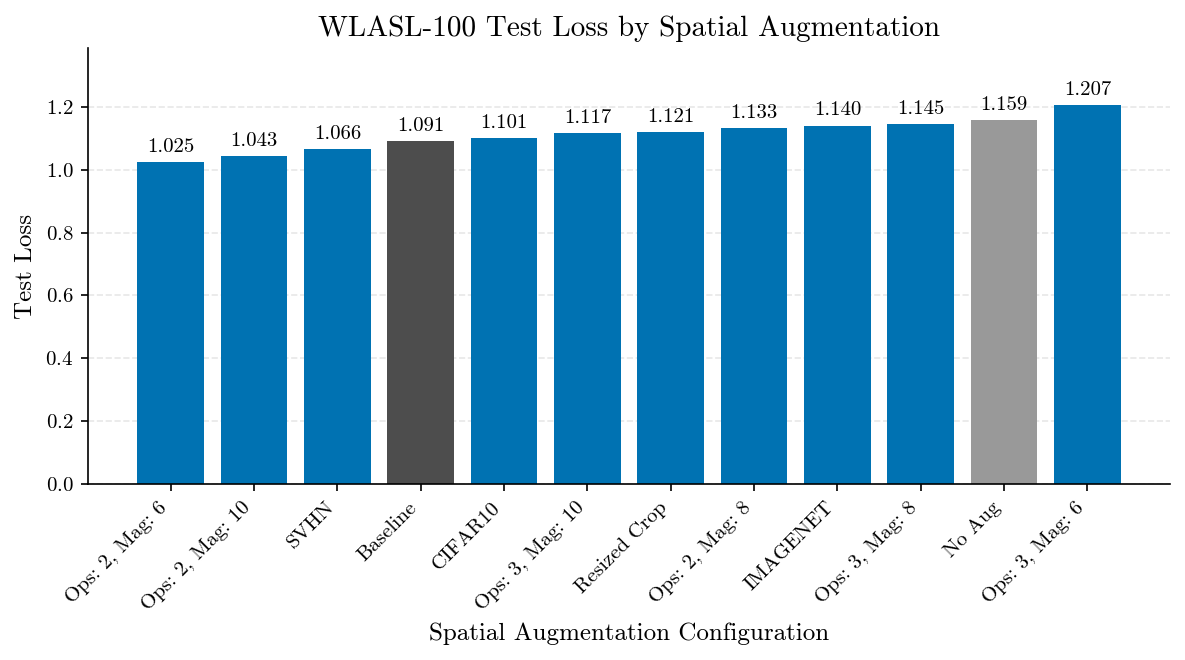

In [6]:
aug_type = 'spatial'
aug_df = subdf[subdf["type"].isin([aug_type, 'control'])]
# display(aug_df.sort_values(loss_name, ascending=True))

# Sort and prepare data
df_sorted = aug_df.sort_values(loss_name, ascending=True).copy()
df_sorted["config_name"] = df_sorted["config path"].apply(lambda x: Path(x).stem)

fig, ax = plot_bar_chart(
    [aug_name_mapper(x, name_maps[aug_type]) for x in df_sorted["config_name"]],
    df_sorted[loss_name],
    title=f"{split_name_mapper(split_name)} {set_name.capitalize()} Loss by {aug_type.capitalize()} Augmentation",
    xlabel=f"{aug_type.capitalize()} Augmentation Configuration",
    ylabel=f"{set_name.capitalize()} Loss",
    palette=suggest_palette(df_sorted["config_name"], recognise_controls=True)
)
# ax.grid(axis='y', linestyle='--', alpha=0.7)  # horizontal grid lines on y-axis
plt.savefig((results_dir / aug_type).with_suffix('.pdf'))
plt.show()



### Temporal augs

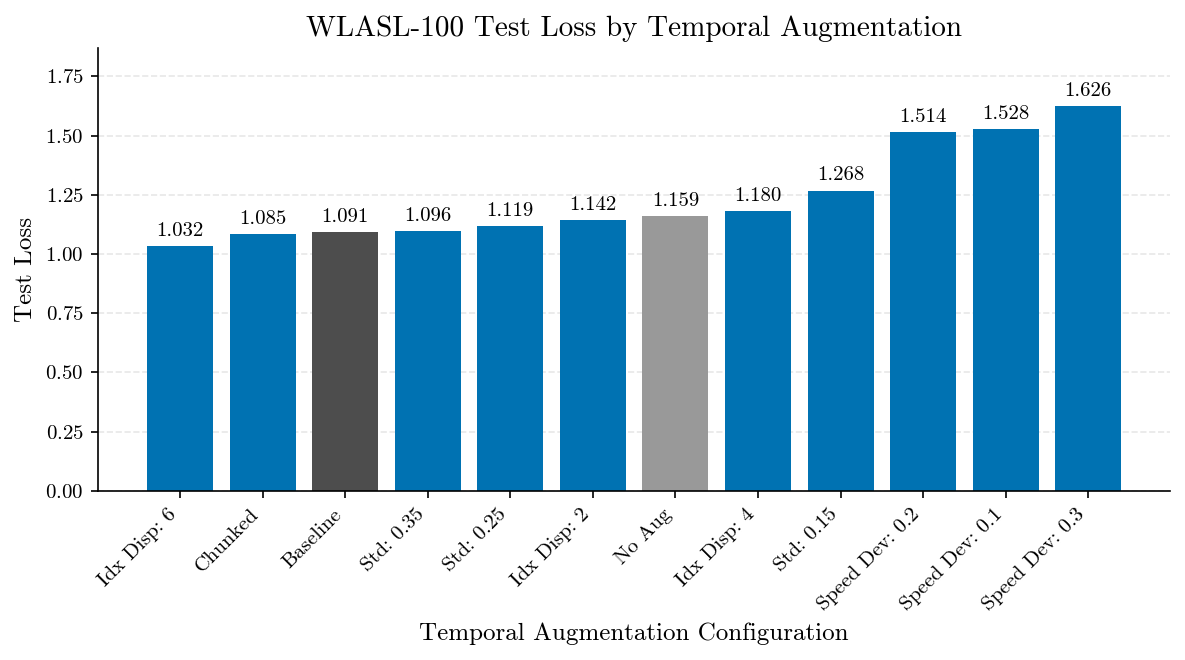

In [7]:
aug_type = 'temporal'
aug_df = subdf[subdf["type"].isin([aug_type, 'control'])]
# display(aug_df.sort_values(loss_name, ascending=True))

# Sort and prepare data
df_sorted = aug_df.sort_values(loss_name, ascending=True).copy()
df_sorted['config_name'] = df_sorted['config path'].apply(lambda x: Path(x).stem)

fig, ax = plot_bar_chart(
    [aug_name_mapper(x, name_maps[aug_type]) for x in df_sorted["config_name"]],
    df_sorted[loss_name],
    title=f"{split_name_mapper(cast(AVAIL_SPLITS, split_name))} {set_name.capitalize()} Loss by {aug_type.capitalize()} Augmentation",
    xlabel=f"{aug_type.capitalize()} Augmentation Configuration",
    ylabel=f"{set_name.capitalize()} Loss",
    palette=suggest_palette(df_sorted["config_name"], recognise_controls=True)
)
# ax.grid(axis='y', linestyle='--', alpha=0.7)  # horizontal grid lines on y-axis
plt.savefig((results_dir / aug_type).with_suffix('.pdf'))
plt.show()